<a href="https://colab.research.google.com/github/ASaragga/GRF/blob/main/VaR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nota: No Google Colab por vezes aparecem mensagens resultantes de uma brincadeira que o Google Colab decidiu fazer no dia 1 Abril de 2024, mas que mantém. Podemos retirar essas interrupções em Settings > Miscellaneous > Power Level, escolhendo: No Power

# Instalação

Vamos instalar as bibliotecas:  `Caramel.j` e `HypothesisTests.jl`.

`Plots.jl` a biblioteca de gráficos que iremos também utilizar, faz parte do muito reduzido conjunto de bibliotecas que já vêm instaladas no Google Colab, não sendo por isso necessário fazer Pkg.add("Plots")

In [33]:
import Pkg
Pkg.add(url="https://github.com/ASaragga/Caramel.jl")
Pkg.add("HypothesisTests");

    Updating git-repo `https://github.com/ASaragga/Caramel.jl`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [ ]:
using Caramel
using HypothesisTests
using Plots

Podemos guardar os gráficos criados por Plots, fazendo: `savefig(grafico, "nome_ficheiro")`

Exemplo: `savefig(grf01, "output.png")`

# Obtenção de Cotações e Visualização

Pretendemos obter as cotações diárias (ajustadas) de fecho da Apple, entre 1 Outubro 2020 e 15 de Março de 2025. Podemos, claro, escolher outras ações e períodos!

Para ações cotadas na Euronext Lisbon devemos acrescentar o sufixo (.LS) referente à bolsa,  e.g. "JMT.LS" para as ações da Jerónimo Martins.

In [34]:
simbolos = ["AAPL"]                # "AAPL" é o símbolo da Apple na bolsa NASDAQ

preços = get_prices(simbolos, Date(2020,10,01), Date(2025,03,15))
show(preços)

1118×8 DataFrame
  Row │ ticker  date        open     high     low      close    adjclose  vol
      │ String  Date        Float64  Float64  Float64  Float64  Float64   Float64
──────┼─────────────────────────────────────────────────────────────────────────────
    1 │ AAPL    2020-10-01  114.711  114.789  112.946   116.79   113.882  1.13229e8
    2 │ AAPL    2020-10-02  110.079  112.497  109.426   113.02   110.206  1.41108e8
    3 │ AAPL    2020-10-05  111.074  113.745  110.722   116.5    113.599  1.03598e8
    4 │ AAPL    2020-10-06  112.819  113.228  109.455   113.16   110.342  1.57477e8
    5 │ AAPL    2020-10-07  111.766  112.673  111.288   115.08   112.214  9.44373e7
    6 │ AAPL    2020-10-08  113.355  113.501  111.737   114.97   112.107  8.13985e7
    7 │ AAPL    2020-10-09  112.409  114.087  112.058   116.97   114.057  9.80041e7
    8 │ AAPL    2020-10-12  117.07   122.063  116.31    124.4    121.302  2.34245e8
    9 │ AAPL    2020-10-13  122.151  122.268  116.671   121.1    1

Selecionamos todas as linhas (:) mas apenas a coluna `:adjclose` para criar um vector contendo somente as cotações de fecho ajustadas em vez da totalidade do dataframe que tinhamos antes

In [35]:
adjclose = preços[:, :adjclose];
# O ponto e virgula no final, faz com que o resultado do comando não seja impresso.


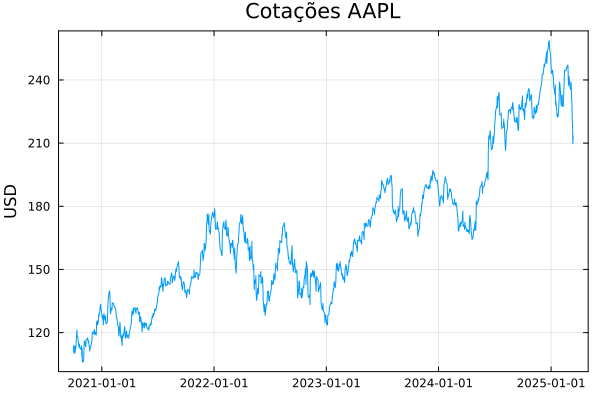

In [37]:
fig1 = plot(preços[:,:date], adjclose, title="Cotações $(simbolos[1])",legend = false,ylabel="USD", framestyle = :box)

# Calcular Retornos

Para analisar séries cronológicas é normalmente mais indicado a utilização de retornos logarítmicos: $\log(P_t/P_{t-1})$. Julia denota por $\log(\cdot)$ a função que calcula o logarítmo de base e. Para agregação sectional, por exemplo se pretendermos calcular o retorno de uma carteira, devemos antes utilizar os retornos simples dos ativos constituintes da carteira: $(P_t-P_{t-1})/P_{t-1}$

In [38]:
# Agora que inspecionámos a evolução das cotações, vamos calcular os retornos

logr = get_returns(simbolos, Date(2020,10,01),Date(2025,01,01))
show(logr)

1068×2 DataFrame
  Row │ date        AAPL
      │ Date        Float64?
──────┼──────────────────────────
    1 │ 2020-10-02  -0.0328126
    2 │ 2020-10-05   0.0303263
    3 │ 2020-10-06  -0.0290884
    4 │ 2020-10-07   0.0168247
    5 │ 2020-10-08  -0.000956321
    6 │ 2020-10-09   0.0172464
    7 │ 2020-10-12   0.0615845
    8 │ 2020-10-13  -0.0268855
    9 │ 2020-10-14   0.000742993
   10 │ 2020-10-15  -0.00396859
   11 │ 2020-10-16  -0.0140996
  ⋮   │     ⋮            ⋮
 1059 │ 2024-12-17   0.00967262
 1060 │ 2024-12-18  -0.0216545
 1061 │ 2024-12-19   0.0069902
 1062 │ 2024-12-20   0.018641
 1063 │ 2024-12-23   0.00306027
 1064 │ 2024-12-24   0.0114127
 1065 │ 2024-12-26   0.00317065
 1066 │ 2024-12-27  -0.0133306
 1067 │ 2024-12-30  -0.0133522
 1068 │ 2024-12-31  -0.00708292
                1047 rows omitted

In [40]:
returns = logr[:, :AAPL];

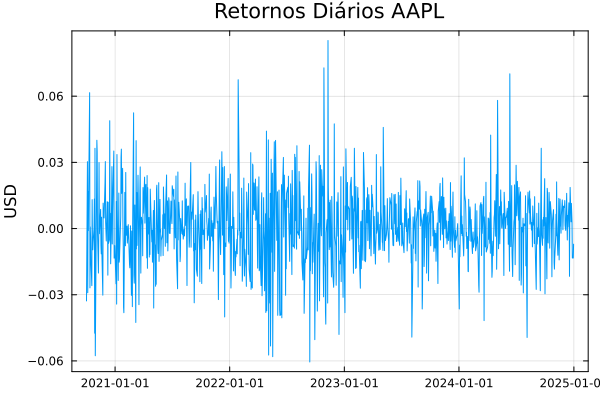

In [41]:
fig2 = plot(logr[:,:date], returns, title="Retornos Diários $(simbolos[1])",legend = false, ylabel="USD", framestyle = :box)

## Média e Volatilidade

Iremos calcular de seguida (i) a média (μ) e o (ii) desvio-padrão (σ) dos retornos diários,

In [ ]:
mu = mean(returns)
sigma = std(returns)
println("μ = ", mu)
println("σ = ", sigma)

μ = 0.0007367790262172284
σ = 0.017069944728404583


## Histograma

Podemos visualizar o histograma dos retorns diário usando o método `histogram()` da bilioteca Plots.jl

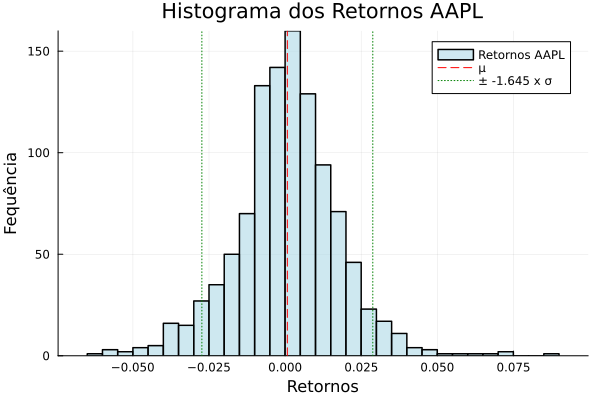

In [ ]:
fig3 = histogram(returns,
          bins=30,  # Numero de barras
          color=:lightblue,
          label="Retornos $(simbolo)",
          xlabel="Retornos",
          ylabel="Fequência",
          title="Histograma dos Retornos $(simbolo)",
          grid=true,
          fillalpha=0.6,  # Transparencia das barras
          linecolor=:black,
          linewidth=1.5)

# Adicionamos linhas verticais (vline!) para a média e z * desvio-padrão
z = - 1.645   # quantil a 5% se distribuição normal(0,1)

vline!([mu], linecolor=:red, linestyle=:dash, label="μ")
vline!([mu + z * sigma, mu - z * sigma],
       linecolor=:green, linestyle=:dot, label="± $(z) x σ")

display(plot!(fig3))

O gráfico (fig3) sugere que a observação de valores extremos ocorreu com elevada frequência

Primeiro ajustamos a distribuição Normal aos retornos observados, o que é muito simples

In [42]:
μ, σ = mean(returns), std(returns)
normal_fit = Normal(μ, σ)
println("Parâmetros: ", normal_fit)


Parâmetros: Normal{Float64}(μ=0.0007367787104929287, σ=0.017069932635934752)


# Valor-em-Risco (VaR)

## Abordagem Analítica

Vamos agora determinar o valor em risco de acordo com a abordagem analítica.
1.   Escolhemos a distribuição de probabilidades.
2.   Selecionamos o período da amostra e estimamos o desvio-padrão ($\sigma_p$) da distribuição escolhida com base nos dados da amostra
  *   Podemos também considerar o valor esperado dos retornos $\mathbb{E}[\mu]$ com base num modelo de equilíbrio forward-looking, como CAPM.
  *   Pelo contrário, normalmente a volatilidade é estimada com base em dados históricos.
3.   Com base na distribução escolhida, calculamos o $\alpha$-quantil ($z_\alpha$) desejado.

Iremos considerar que $\mathbb{E}[\mu]\approx 0$, donde que neste caso teremos que

$$\text{VaR}_\alpha = - z_\alpha * \sigma_p * V_p$$

onde $V_p$ é o valor do portfolio. Assumimos que a distribuição de retornos é a Normal.

In [43]:
V = 100_000
𝛼 = 0.05

z_𝛼 = quantile(Normal(),𝛼)
VaR = - z_𝛼 * σ * V
println("Abordagem Analítica: VaR(𝛼=$(𝛼)) = ", VaR)

Abordagem Analítica: VaR(𝛼=0.05) = 2807.754060803459


# Simulação Histórica

O cálculo do VaR por simulação histórica requer apenas que determinemos o ponto de corte correspondente ao $\alpha$-quantil para o período da amostra.

In [44]:
VaR = - quantile(returns, 𝛼) * V
println("Simulação Histórica: VaR(𝛼=$(𝛼)) = ", VaR)

Simulação Histórica: VaR(𝛼=0.05) = 2757.5297917272646
